# Model 1: Basic Seq2Seq (LSTM, no attention)

**Prerequisites:** run `01_preprocessing.ipynb` first to generate the processed data files.

**Environments:** runs locally and in Google Colab. In Colab, use a GPU runtime (Runtime > Change runtime type > T4 GPU) and run `01_preprocessing.ipynb` in the same session beforehand.

In [ ]:
import json
import sys
from pathlib import Path

import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    PROCESSED_DIR = Path("processed")
    CHECKPOINT_PATH = Path("best_basic.pt")
else:
    PROCESSED_DIR = Path("../../data/processed")
    CHECKPOINT_PATH = Path("../../results/best_basic.pt")

CHECKPOINT_PATH.parent.mkdir(exist_ok=True)

PAD_IDX, SOS_IDX, EOS_IDX, UNK_IDX = 0, 1, 2, 3
BATCH_SIZE = 32

with open(PROCESSED_DIR / "token2idx.json") as f:
    tokenToIdx = json.load(f)
idxToToken = {v: k for k, v in tokenToIdx.items()}


def encode(tokens: list[str]) -> list[int]:
    """
    Converts a list of string tokens to an integer ID sequence with SOS/EOS.
    @param tokens: List of string tokens to encode.
    @return: List of integer token IDs with SOS at index 0 and EOS at the end.
    """
    return [SOS_IDX] + [tokenToIdx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]


def decode(ids: list[int]) -> list[str]:
    """
    Converts integer token IDs back to string tokens, skipping special tokens.
    @param ids: List of integer token IDs.
    @return: List of string tokens with PAD, SOS, and EOS removed.
    """
    return [idxToToken[i] for i in ids if i not in {PAD_IDX, SOS_IDX, EOS_IDX}]


with open(PROCESSED_DIR / "train.json") as f:
    trainDf = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "dev.json") as f:
    devDf = pd.DataFrame(json.load(f))
with open(PROCESSED_DIR / "test.json") as f:
    testDf = pd.DataFrame(json.load(f))

print(f"Vocabulary size : {len(tokenToIdx):,}")
print(
    f"Q&A pairs -- train: {len(trainDf):,}  dev: {len(devDf):,}  test: {len(testDf):,}"
)


class WikiQADataset(Dataset):
    """
    PyTorch Dataset wrapping the pre-encoded WikiQA question-answer pairs.
    @param dataFrame: DataFrame with 'q_ids' and 'a_ids' columns of integer ID lists.
    """

    def __init__(self, dataFrame: pd.DataFrame):
        self.qIds = dataFrame["q_ids"].tolist()
        self.aIds = dataFrame["a_ids"].tolist()

    def __len__(self) -> int:
        return len(self.qIds)

    def __getitem__(self, idx: int):
        return torch.tensor(self.qIds[idx]), torch.tensor(self.aIds[idx])


def collateBatch(batch: list) -> dict:
    """
    Pads a list of (question, answer) tensor pairs into fixed-length batch tensors.
    @param batch: List of (question tensor, answer tensor) pairs from WikiQADataset.
    @return: Dict with keys 'src', 'tgt', and 'srcLens' as batch tensors.
    """
    questions, answers = zip(*batch)
    src = pad_sequence(questions, batch_first=True, padding_value=PAD_IDX)
    tgt = pad_sequence(answers, batch_first=True, padding_value=PAD_IDX)
    return {
        "src": src,
        "tgt": tgt,
        "srcLens": torch.tensor([len(q) for q in questions]),
    }


trainLoader = DataLoader(
    WikiQADataset(trainDf), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collateBatch
)
devLoader = DataLoader(
    WikiQADataset(devDf), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collateBatch
)
testLoader = DataLoader(
    WikiQADataset(testDf), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collateBatch
)

print(
    f"Batches -- train: {len(trainLoader)}  dev: {len(devLoader)}  test: {len(testLoader)}"
)

Vocabulary size : 6,905
Q&A pairs -- train: 728  dev: 98  test: 291
Batches -- train: 23  dev: 4  test: 10


---

## Part 2: Model architecture

A standard LSTM encoder-decoder with no attention.

The encoder reads the full question and compresses it into a hidden state `(h_n, c_n)`. The decoder is stepped one token at a time, initialised with that hidden state. During training, teacher forcing randomly replaces the decoder's own previous prediction with the ground-truth token.

In [11]:
import torch.nn as nn

# ── Hyperparameters ────────────────────────────────────────────────────────────
EMBED_DIM = 256
HIDDEN_DIM = 256
N_LAYERS = 1
DROPOUT = 0.5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


In [12]:
import torch.nn as nn


class Encoder(nn.Module):
    """
    LSTM encoder that compresses an input token sequence into a hidden state.
    @param vocabSize: Number of tokens in the vocabulary.
    @param embedDim: Dimensionality of the token embedding vectors.
    @param hiddenDim: Number of hidden units in the LSTM.
    @param nLayers: Number of stacked LSTM layers.
    @param dropout: Dropout probability applied to embeddings and between LSTM layers.
    """

    def __init__(
        self,
        vocabSize: int,
        embedDim: int,
        hiddenDim: int,
        nLayers: int,
        dropout: float,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            nLayers,
            batch_first=True,
            dropout=dropout if nLayers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src: torch.Tensor, srcLens: torch.Tensor):
        embedded = self.dropout(self.embedding(src))
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, srcLens.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.lstm(packed)
        return hidden


class Decoder(nn.Module):
    """
    LSTM decoder that generates one output token per step given a hidden state.
    @param vocabSize: Number of tokens in the vocabulary.
    @param embedDim: Dimensionality of the token embedding vectors.
    @param hiddenDim: Number of hidden units in the LSTM.
    @param nLayers: Number of stacked LSTM layers.
    @param dropout: Dropout probability applied to embeddings.
    """

    def __init__(
        self,
        vocabSize: int,
        embedDim: int,
        hiddenDim: int,
        nLayers: int,
        dropout: float,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocabSize, embedDim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            embedDim,
            hiddenDim,
            nLayers,
            batch_first=True,
            dropout=dropout if nLayers > 1 else 0.0,
        )
        self.fc = nn.Linear(hiddenDim, vocabSize)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token: torch.Tensor, hidden):
        embedded = self.dropout(self.embedding(token.unsqueeze(1)))
        output, hidden = self.lstm(embedded, hidden)
        logits = self.fc(output.squeeze(1))
        return logits, hidden


class Seq2Seq(nn.Module):
    """
    Full encoder-decoder sequence-to-sequence model combining Encoder and Decoder.
    @param encoder: Encoder instance that produces hidden states from source sequences.
    @param decoder: Decoder instance that generates tokens step-by-step.
    """

    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(
        self,
        src: torch.Tensor,
        srcLens: torch.Tensor,
        tgt: torch.Tensor,
        teacherForcingRatio: float = 0.5,
    ):
        batchSize, tgtLen = tgt.shape
        vocabSize = self.decoder.fc.out_features

        hidden = self.encoder(src, srcLens)

        outputs = torch.zeros(batchSize, tgtLen, vocabSize, device=src.device)
        token = tgt[:, 0]  # <sos>

        for t in range(1, tgtLen):
            logits, hidden = self.decoder(token, hidden)
            outputs[:, t] = logits
            useTeacher = torch.rand(1).item() < teacherForcingRatio
            token = tgt[:, t] if useTeacher else logits.argmax(dim=-1)

        return outputs

In [13]:
encoder = Encoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(len(tokenToIdx), EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model = Seq2Seq(encoder, decoder).to(DEVICE)

nParams = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {nParams:,}")

# Smoke test -- one forward pass
batch = next(iter(trainLoader))
out = model(batch["src"].to(DEVICE), batch["srcLens"], batch["tgt"].to(DEVICE))
print(
    f"Output shape: {out.shape}  (expected [batch={BATCH_SIZE}, tgt_len, vocab={len(tokenToIdx)}])"
)

Trainable parameters: 6,362,617
Output shape: torch.Size([32, 32, 6905])  (expected [batch=32, tgt_len, vocab=6905])


---

## Part 3: Training

- **Loss:** cross-entropy, `<pad>` positions ignored
- **Optimiser:** Adam
- **Gradient clipping:** norm clipped to 1.0 to prevent exploding gradients (common with LSTMs)
- **Checkpoint:** best model by validation loss is saved to `CHECKPOINT_PATH`

In [14]:
import math
import time
import matplotlib.pyplot as plt

EPOCHS = 30
LEARNING_RATE = 5e-4
CLIP = 1.0
TEACHER_FORCING = 0.7
PATIENCE = 3

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)


def trainEpoch(
    model: Seq2Seq,
    loader: DataLoader,
    optimizer,
    criterion,
    clip: float,
) -> float:
    """
    Runs one full training pass over the provided data loader.
    @param model: The Seq2Seq model to train.
    @param loader: DataLoader yielding batches with 'src', 'tgt', and 'srcLens' keys.
    @param optimizer: Optimizer instance for parameter updates.
    @param criterion: Loss function (CrossEntropyLoss with PAD ignored).
    @param clip: Maximum gradient norm for gradient clipping.
    @return: Mean cross-entropy loss over all batches.
    """
    model.train()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]

        optimizer.zero_grad()
        output = model(src, srcLens, tgt, TEACHER_FORCING)

        loss = criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        )
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        totalLoss += loss.item()
    return totalLoss / len(loader)


@torch.no_grad()
def evaluate(model: Seq2Seq, loader: DataLoader, criterion) -> float:
    """
    Evaluates the model on a data loader without updating parameters.
    @param model: The Seq2Seq model to evaluate.
    @param loader: DataLoader yielding batches with 'src', 'tgt', and 'srcLens' keys.
    @param criterion: Loss function (CrossEntropyLoss with PAD ignored).
    @return: Mean cross-entropy loss over all batches.
    """
    model.eval()
    totalLoss = 0.0
    for batch in loader:
        src = batch["src"].to(DEVICE)
        tgt = batch["tgt"].to(DEVICE)
        srcLens = batch["srcLens"]
        output = model(src, srcLens, tgt, teacherForcingRatio=0.0)
        totalLoss += criterion(
            output[:, 1:].reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1)
        ).item()
    return totalLoss / len(loader)

In [15]:
trainLosses, valLosses = [], []
bestValLoss = float("inf")
epochsNoImprove = 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    trainLoss = trainEpoch(model, trainLoader, optimizer, criterion, CLIP)
    valLoss = evaluate(model, devLoader, criterion)
    elapsed = time.time() - t0

    trainLosses.append(trainLoss)
    valLosses.append(valLoss)

    marker = ""
    if valLoss < bestValLoss:
        bestValLoss = valLoss
        epochsNoImprove = 0
        torch.save(
            {
                "model_state": model.state_dict(),
                "tokenToIdx": tokenToIdx,
                "embed_dim": EMBED_DIM,
                "hidden_dim": HIDDEN_DIM,
                "n_layers": N_LAYERS,
                "dropout": DROPOUT,
            },
            CHECKPOINT_PATH,
        )
        marker = "  ✓ saved"
    else:
        epochsNoImprove += 1
        if epochsNoImprove >= PATIENCE:
            print(
                f"Early stopping at epoch {epoch}  (no improvement for {PATIENCE} epochs)"
            )
            break

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train loss {trainLoss:.4f} (ppl {math.exp(trainLoss):6.2f}) | "
        f"val loss {valLoss:.4f} (ppl {math.exp(valLoss):6.2f}) | "
        f"{elapsed:.1f}s{marker}"
    )

print(f"\nBest val loss: {bestValLoss:.4f}")

Epoch 01/30 | train loss 8.7370 (ppl 6229.19) | val loss 8.1088 (ppl 3323.46) | 2.4s  ✓ saved
Epoch 02/30 | train loss 7.3139 (ppl 1501.05) | val loss 7.6786 (ppl 2161.51) | 2.6s  ✓ saved
Epoch 03/30 | train loss 6.7894 (ppl 888.39) | val loss 7.7007 (ppl 2209.96) | 2.6s
Epoch 04/30 | train loss 6.6888 (ppl 803.39) | val loss 7.7744 (ppl 2378.94) | 2.3s
Early stopping at epoch 5  (no improvement for 3 epochs)

Best val loss: 7.6786


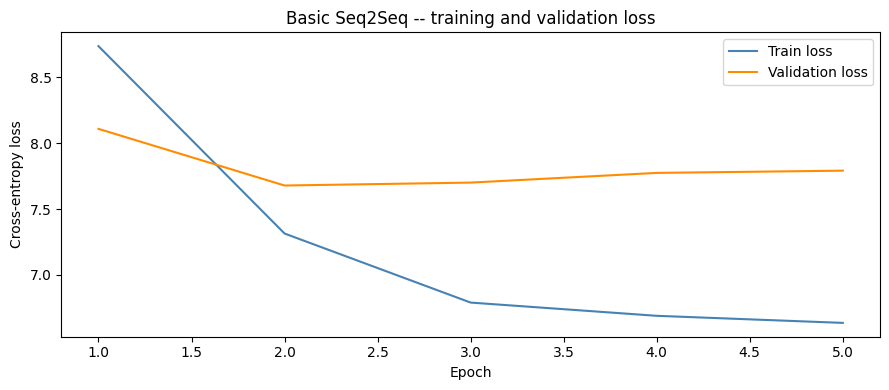

In [16]:
epochsRange = range(1, len(trainLosses) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochsRange, trainLosses, label="Train loss", color="steelblue")
plt.plot(epochsRange, valLosses, label="Validation loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Basic Seq2Seq -- training and validation loss")
plt.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_PATH.parent / "basic_loss_curves.png", dpi=150)
plt.show()

---

## Part 5: Inference

Load the best checkpoint and generate answers greedily (no teacher forcing).

In [17]:
import re
import nltk

nltk.download("punkt_tab", quiet=True)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

ckptTokenToIdx = checkpoint["tokenToIdx"]
ckptEncoder = Encoder(
    len(ckptTokenToIdx),
    checkpoint["embed_dim"],
    checkpoint["hidden_dim"],
    checkpoint["n_layers"],
    checkpoint["dropout"],
)
ckptDecoder = Decoder(
    len(ckptTokenToIdx),
    checkpoint["embed_dim"],
    checkpoint["hidden_dim"],
    checkpoint["n_layers"],
    checkpoint["dropout"],
)
bestModel = Seq2Seq(ckptEncoder, ckptDecoder).to(DEVICE)
bestModel.load_state_dict(checkpoint["model_state"])
bestModel.eval()

ckptIdxToToken = {v: k for k, v in ckptTokenToIdx.items()}


def tokenizeInput(text: str) -> list[str]:
    """
    Converts a raw question string to a list of lowercase word tokens.
    @param text: Raw input question string.
    @return: List of lowercase string tokens.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9'? ]", " ", text)
    return nltk.word_tokenize(text)


@torch.no_grad()
def answer(question: str, maxLen: int = 50) -> str:
    """
    Generates a greedy answer for a natural-language question using the best checkpoint.
    @param question: Raw input question string.
    @param maxLen: Maximum number of tokens to generate before stopping.
    @return: Generated answer as a single space-separated string.
    """
    tokens = tokenizeInput(question)
    srcIds = [SOS_IDX] + [ckptTokenToIdx.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    src = torch.tensor(srcIds, device=DEVICE).unsqueeze(0)
    srcLens = torch.tensor([len(srcIds)])

    hidden = bestModel.encoder(src, srcLens)
    token = torch.tensor([SOS_IDX], device=DEVICE)

    result = []
    for _ in range(maxLen):
        logits, hidden = bestModel.decoder(token, hidden)
        token = logits.argmax(dim=-1)
        if token.item() == EOS_IDX:
            break
        result.append(ckptIdxToToken.get(token.item(), "<unk>"))

    return " ".join(result)


questions = [
    "how are glacier caves formed?",
    "what is the speed of light?",
    "where is the eiffel tower located?",
]
for q in questions:
    print(f"Q: {q}")
    print(f"A: {answer(q)}")
    print()

Q: how are glacier caves formed?
A: the the is the

Q: what is the speed of light?
A: the the the is

Q: where is the eiffel tower located?
A: the the is the



---

## Results and interpretation

### Training summary

| Epoch | Train loss | Train PPL | Val loss | Val PPL |
|-------|-----------|-----------|----------|---------|
| 1 | 8.7370 | 6229 | 8.1088 | 3323 |
| **2** | **7.3139** | **1501** | **7.6786** | **2162** |
| 3 | 6.7894 | 888 | 7.7007 | 2210 |
| 4 | 6.6888 | 803 | 7.7744 | 2379 |
| 5 | - | - | - | early stop |

Early stopping triggered after epoch 5. Best checkpoint: **epoch 2, val loss 7.6786 (PPL 2162)**.

### What the numbers show

Validation loss improves over the first two epochs (8.11 → 7.68) then climbs immediately, indicating the model overfits very early. The gap between train loss (6.69 at epoch 4) and val loss (7.77) exceeds 1.0 nat; the model memorises the 728 training pairs rather than learning generalisable patterns.

A PPL of 2162 means that at each decoding step the model is as uncertain as if it were choosing uniformly from roughly 2,162 tokens. For reference, a competent conversational model typically sits below PPL 50. The value here confirms the model has not learned meaningful language structure.

The MAX_LENGTH filter (answers up to 30 tokens, questions up to 20 tokens) keeps the embedding layer small. With vocabulary 6,905 and embed_dim=256, each embedding table holds only ~1.8M parameters, accounting for most of the 6.4M total. Training is fast at ~2.5s per epoch (23 batches of 32).

### What the inference output shows

Every question produces a short stop-word sequence — "the the is the" or "the the the is" — with EOS firing after 4 tokens. The decoder ignores the encoder state and emits the most frequent tokens in the training data in a fixed pattern. No question-specific information is encoded at all.

The short output length will still penalise BLEU scores due to the brevity penalty, since references are typically 10–25 tokens long.

### Why mode collapse happens

Two compounding causes explain the failure:

**Information bottleneck.** The encoder compresses the entire question into a single hidden state vector of 256 dimensions. With only 728 training pairs, the decoder never receives a reliable training signal to use that vector: the same hidden state maps to wildly different reference answers depending on the question. The path of least resistance is to ignore it and predict the marginal token distribution of the training answers, where "the" is the most frequent token.

**Exposure bias.** During training, teacher forcing feeds ground-truth tokens as decoder input 70% of the time. At inference the decoder sees its own previous prediction instead. The model was never trained to recover from emitting stop words, so once it produces them the pattern repeats until EOS fires.

**Dataset size.** Seq2seq models trained from scratch typically require tens of thousands of sentence pairs before content words begin to appear in outputs. 728 pairs (the result of applying the MAX_LENGTH filter to the Label=1 subset of WikiQA) is far below that threshold. The model simply does not see enough varied question-answer contexts to learn conditional generation.